# atlm_pro MP1 — Continued Pretraining of SmolLM2-135M

**Project goal.** Continue the **pretraining** of the base `SmolLM2-135M`
language model on a corpus of raw job-description text, adapting it to the
job-postings domain. This is plain next-token prediction — no labels, no
queries (turning the model into a recruiter-query assistant is MP2's job).

**Optimization experiment.** The required knob is **full fine-tuning vs. LoRA**:
two controlled runs with everything else held constant, compared by perplexity
and sample generations.

**This notebook** runs end to end:

1. **Dataset exploration** (§1–3) — examine the two candidate datasets and
   justify the training corpus.
2. **Continued pretraining** (§4) — full fine-tuning vs LoRA.
3. **Results** (§5) — loss curves, three-way perplexity, before/after generations.
4. **Interactive testing** (§6) — feed the trained model your own prompts.

The two datasets examined are:

1. **Djinni** — real IT job postings (Hugging Face).
2. **LinkedIn** — real cross-industry job postings (Kaggle).

## 0. Setup

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

# Locate the project root (the folder that contains data/).
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
JOBS = PROJECT_ROOT / "data" / "jobs"

print("Project root :", PROJECT_ROOT)
print("Jobs data dir:", JOBS)
assert JOBS.exists(), f"data/jobs not found starting from {Path.cwd()}"

Project root : /home/logus/env/iscte/atlm_pro
Jobs data dir: /home/logus/env/iscte/atlm_pro/data/jobs


## 1. Djinni — the core dataset

[`lang-uk/recruitment-dataset-job-descriptions-english`](https://huggingface.co/datasets/lang-uk/recruitment-dataset-job-descriptions-english)
— real IT job postings scraped from the Djinni platform (2020–2023), MIT-licensed.
This is the **core dataset** for training, validation and in-domain testing.

In [2]:
djinni = pd.read_parquet(JOBS / "djinni" / "train-00000-of-00001.parquet")
djinni = djinni.drop(columns=["__index_level_0__"], errors="ignore")

print(f"shape: {djinni.shape[0]:,} rows x {djinni.shape[1]} columns\n")
djinni.dtypes

shape: 141,897 rows x 9 columns



Position                 str
Long Description         str
Company Name             str
Exp Years                str
Primary Keyword          str
English Level            str
Published                str
Long Description_lang    str
id                       str
dtype: object

In [3]:
n_unique = djinni["Long Description"].nunique()
print(f"unique 'Long Description': {n_unique:,}  ({n_unique / len(djinni):.1%} of rows)")
djinni.head(3)

unique 'Long Description': 141,897  (100.0% of rows)


,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id
0,10 + Blockchain Nodes / Masternodes to set up,"*Requirements*\r\n\r\nWe're looking for a long term collaboration with someone that has an experience in crypto, mas...",MyCointainer,2y,Sysadmin,intermediate,2020-10-01T00:00:00+03:00,en,c0ca96e7-85df-50df-a64e-d934cd02a170
1,10 .NET Developers (Middle and Senior level),"Greetings! My name is Maria, I am in urgent need to find a team of 10 .NET Developers (Middle and Senior level) to j...",TechScout.tech,2y,.NET,intermediate,2022-03-01T00:00:00+02:00,en,64f4b7ea-36e4-5bdd-a8b1-185f32f7dc7f
2,"10X Engineer (co-founder, #4 employee, USD 11-12k, 1-4% equity)",**Product**\r\nThe product is a live video chat and co-browsing with website visitors. It helps companies generate m...,Innoteka,5y,JavaScript,fluent,2021-07-01T00:00:00+03:00,en,b9a1303e-dd0c-5ed1-8f62-be2bc4c7da4f


count    141897.0
mean       1801.0
std         973.0
min          51.0
25%        1109.0
50%        1629.0
75%        2284.0
max       12578.0
Name: Long Description, dtype: float64


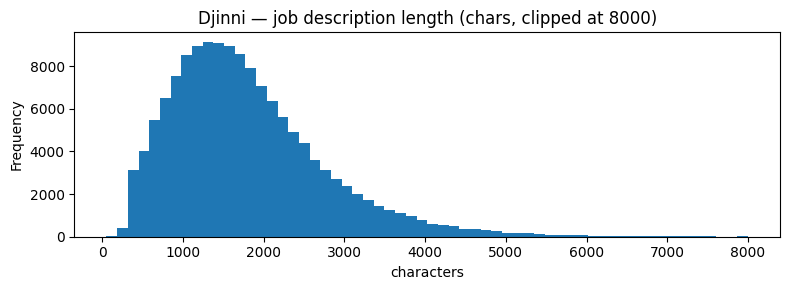

In [4]:
lengths = djinni["Long Description"].str.len()
print(lengths.describe().round(0))

ax = lengths.clip(upper=8000).plot.hist(
    bins=60, figsize=(8, 3),
    title="Djinni — job description length (chars, clipped at 8000)")
ax.set_xlabel("characters")
plt.tight_layout()
plt.show()

45 distinct primary keywords (tech / domain)

Primary Keyword
JavaScript         17903
Java                8712
DevOps              7979
.NET                7826
Other               7536
QA Automation       7047
Marketing           6933
QA                  6774
Node.js             6416
PHP                 5740
Python              5735
Project Manager     4618
HR                  4063
Design              4020
Sales               4014
Name: count, dtype: int64


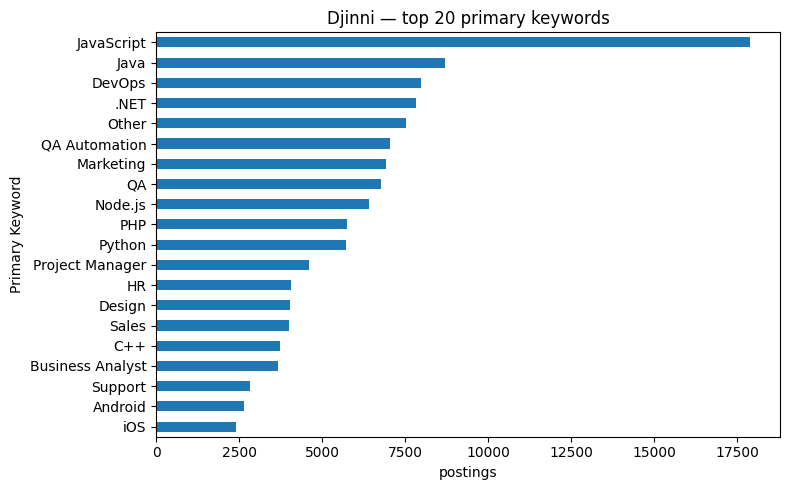

In [5]:
kw = djinni["Primary Keyword"].value_counts()
print(f"{kw.size} distinct primary keywords (tech / domain)\n")
print(kw.head(15))

ax = kw.head(20).iloc[::-1].plot.barh(
    figsize=(8, 5), title="Djinni — top 20 primary keywords")
ax.set_xlabel("postings")
plt.tight_layout()
plt.show()

In [6]:
print("Experience required:")
print(djinni["Exp Years"].value_counts(), "\n")
print("English level required:")
print(djinni["English Level"].value_counts(dropna=False))

Experience required:
Exp Years
3y        49996
2y        36150
5y        27772
1y        22007
no_exp     5972
Name: count, dtype: int64 

English level required:
English Level
upper           66948
intermediate    54965
fluent          10583
NaN              7539
pre              1689
basic             173
Name: count, dtype: int64


## 2. LinkedIn — out-of-domain test set

[Kaggle: LinkedIn Job Postings 2023–2024](https://www.kaggle.com/datasets/arshkon/linkedin-job-postings)
— real, **cross-industry** postings. This set is held out entirely from training
and used only to measure how well an IT-trained model **generalises** to other
domains.

In [7]:
linkedin_dir = JOBS / "linkedin"
keep = ["job_id", "title", "description", "company_name", "location",
        "formatted_work_type", "formatted_experience_level", "skills_desc"]
linkedin = pd.read_csv(linkedin_dir / "postings.csv", usecols=keep)

print(f"shape: {linkedin.shape[0]:,} rows x {linkedin.shape[1]} columns")
linkedin.head(3)

shape: 123,849 rows x 8 columns


,job_id,company_name,title,description,location,formatted_work_type,formatted_experience_level,skills_desc
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in New Jersey is seeking an administrative Marketing Coordinator with some...,"Princeton, NJ",Full-time,NaN,Requirements: \n\nWe are seeking a College or Graduate Student (can also be completed with school) with a focus in P...
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committed to serving clients with best practices to help them with change, im...","Fort Collins, CO",Full-time,NaN,NaN
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting applications for an Assistant Restaurant Manager.\nWe offer highly competitive wa...,"Cincinnati, OH",Full-time,NaN,We are currently accepting resumes for FOH - Asisstant Restaurant Management with a strong focus on delivering high ...


In [8]:
print(f"rows                : {len(linkedin):,}")
print(f"unique descriptions : {linkedin['description'].nunique():,}")
print(f"non-null description: {linkedin['description'].notna().sum():,}")
print(f"non-null skills_desc: {linkedin['skills_desc'].notna().sum():,}  "
      f"({linkedin['skills_desc'].notna().mean():.1%})")
print()
print("description length (chars):")
print(linkedin["description"].str.len().describe().round(0))

rows                : 123,849
unique descriptions : 107,827
non-null description: 123,842
non-null skills_desc: 2,439  (2.0%)

description length (chars):
count    123842.0
mean       3766.0
std        2146.0
min           2.0
25%        2176.0
50%        3435.0
75%        4986.0
max       23201.0
Name: description, dtype: float64


`skills_desc` is populated for only ~2% of postings, so it cannot be relied on as a
skills field. The description text itself is rich, and two auxiliary tables provide
structured tags: `jobs/job_skills.csv` (skill categories) and
`jobs/job_industries.csv` (industry), each resolved through the `mappings/` lookups.

In [9]:
# skills_desc is almost always empty -> use the auxiliary skill / industry tables.
skill_name = (pd.read_csv(linkedin_dir / "mappings" / "skills.csv")
                .set_index("skill_abr")["skill_name"])
job_skills = pd.read_csv(linkedin_dir / "jobs" / "job_skills.csv")
job_skills["skill_name"] = job_skills["skill_abr"].map(skill_name)
skills_per_job = job_skills.groupby("job_id")["skill_name"].apply(list)

industry_name = (pd.read_csv(linkedin_dir / "mappings" / "industries.csv")
                   .set_index("industry_id")["industry_name"])
job_industries = pd.read_csv(linkedin_dir / "jobs" / "job_industries.csv")
job_industries["industry_name"] = job_industries["industry_id"].map(industry_name)

print(f"jobs with >=1 skill tag: {skills_per_job.size:,}")
print(f"distinct skill tags    : {skill_name.size}")
print(f"distinct industries    : {industry_name.size}\n")
print("Top 15 industries (LinkedIn is cross-industry, unlike IT-only Djinni):")
print(job_industries["industry_name"].value_counts().head(15))

jobs with >=1 skill tag: 126,807
distinct skill tags    : 35
distinct industries    : 422

Top 15 industries (LinkedIn is cross-industry, unlike IT-only Djinni):
industry_name
Hospitals and Health Care             18326
Retail                                11033
IT Services and IT Consulting         10396
Staffing and Recruiting                9005
Financial Services                     8535
Software Development                   5091
Manufacturing                          3689
Construction                           3445
Banking                                2923
Insurance                              2673
Pharmaceutical Manufacturing           2469
Hospitality                            2455
Telecommunications                     2433
Real Estate                            2326
Industrial Machinery Manufacturing     2143
Name: count, dtype: int64


## 3. Conclusion — dataset decision

| Dataset | Rows | Unique descriptions | Verdict |
|---|---|---|---|
| **Djinni** (IT) | 141,897 | **141,897** | **Core** — train / val / in-domain test |
| **LinkedIn** (cross-industry) | 123,849 | 107,827 | **Out-of-domain test** only |

**Decision.** Train and validate on Djinni; reserve LinkedIn as an unseen
cross-industry test set. This yields a genuine generalisation experiment:
*does an IT-trained job-description model transfer to other industries?*

**Next step.** Section 4 continues the pretraining of `SmolLM2-135M` on the
Djinni corpus (`data/processed/mp1/`, built by `src/prepare_corpus.py`),
comparing full fine-tuning against LoRA.

## 4. Continued pretraining — full fine-tuning vs LoRA

MP1 continues the **pretraining** of the base `SmolLM2-135M` on the raw
job-description corpus in `data/processed/mp1/` — plain next-token prediction,
no labels and no queries.

**Optimization experiment (the required knob):** full fine-tuning vs. LoRA,
with everything else held constant (effective batch size, epochs, schedule, data).

> The heavy runs are also packaged as a standalone script,
> `src/train.py --mode full|lora` — that is how they were executed here (in the
> background, each in its own crash-isolated process). The cells below are the
> same logic, runnable directly in the notebook.

In [10]:
import itertools, json, math, time

import torch
from datasets import load_dataset
from transformers import (AutoModelForCausalLM, AutoTokenizer,
                          DataCollatorForLanguageModeling, Trainer,
                          TrainingArguments, set_seed)
from peft import LoraConfig, get_peft_model

MODEL = "HuggingFaceTB/SmolLM2-135M"            # base model (NOT -Instruct)
RUN = "mp1-135m"                                # this run's output-folder tag
CORPUS = PROJECT_ROOT / "data" / "processed" / "mp1"
OUTPUTS = PROJECT_ROOT / "outputs"
RUN_DIR = OUTPUTS / RUN                         # outputs/mp1-135m/  (full/ lora/ eval.json)
BLOCK_SIZE = 1024
SEED = 42

# --- held constant across both modes ---
EPOCHS = 3
PER_DEVICE_BATCH = 4
GRAD_ACCUM = 4                                  # effective batch = 16
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01

# --- the experiment knob: full fine-tuning vs LoRA ---
MODE_CFG = {
    "full": {"learning_rate": 5e-5},
    "lora": {"learning_rate": 2e-4, "r": 16, "alpha": 32, "dropout": 0.05,
             "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj",
                                "gate_proj", "up_proj", "down_proj"]},
}
print("config ready — base model:", MODEL)

/home/logus/env/iscte/atlm_pro/.venv_atlm_pro/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config ready — base model: HuggingFaceTB/SmolLM2-135M


In [11]:
def tokenize_and_chunk(jsonl_path, tokenizer, block_size=BLOCK_SIZE):
    """Tokenize raw text, mark doc boundaries with EOS, pack into fixed blocks."""
    ds = load_dataset("json", data_files=str(jsonl_path), split="train")

    def tok(batch):
        out = tokenizer(batch["text"])
        for ids in out["input_ids"]:
            ids.append(tokenizer.eos_token_id)
        return {"input_ids": out["input_ids"]}

    ds = ds.map(tok, batched=True, remove_columns=ds.column_names)

    def group(batch):
        ids = list(itertools.chain.from_iterable(batch["input_ids"]))
        n = (len(ids) // block_size) * block_size
        blocks = [ids[i:i + block_size] for i in range(0, n, block_size)]
        return {"input_ids": blocks,
                "attention_mask": [[1] * block_size for _ in blocks]}

    return ds.map(group, batched=True)

In [12]:
def run_training(mode):
    """Continued pretraining in `mode` ('full' or 'lora'); returns a summary dict."""
    cfg = MODE_CFG[mode]
    set_seed(SEED)
    out_dir = RUN_DIR / mode

    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(MODEL)

    if mode == "lora":
        model = get_peft_model(model, LoraConfig(
            r=cfg["r"], lora_alpha=cfg["alpha"], lora_dropout=cfg["dropout"],
            target_modules=cfg["target_modules"], task_type="CAUSAL_LM"))
        model.print_trainable_parameters()
    else:
        n = sum(p.numel() for p in model.parameters())
        print(f"full fine-tuning — trainable params: {n:,} (100%)")

    train_ds = tokenize_and_chunk(CORPUS / "train.jsonl", tokenizer)
    val_ds = tokenize_and_chunk(CORPUS / "val.jsonl", tokenizer)
    print(f"train blocks: {len(train_ds):,} | val blocks: {len(val_ds):,}")

    args = TrainingArguments(
        output_dir=str(out_dir),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=PER_DEVICE_BATCH,
        per_device_eval_batch_size=PER_DEVICE_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=cfg["learning_rate"],
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        bf16=True,
        eval_strategy="steps", eval_steps=50, logging_steps=10,
        save_strategy="no", seed=SEED, report_to=[],
    )
    trainer = Trainer(
        model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
        processing_class=tokenizer,
    )

    t0 = time.time()
    trainer.train()
    minutes = (time.time() - t0) / 60

    out_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(out_dir))
    tokenizer.save_pretrained(str(out_dir))

    final = trainer.evaluate()
    summary = {"mode": mode, "learning_rate": cfg["learning_rate"],
               "minutes": round(minutes, 1),
               "final_val_loss": round(final["eval_loss"], 4),
               "val_perplexity": round(math.exp(final["eval_loss"]), 2)}
    (out_dir / "log_history.json").write_text(
        json.dumps(trainer.state.log_history, indent=1))
    (out_dir / "summary.json").write_text(json.dumps(summary, indent=1))
    print("done:", summary)
    return summary

**Run A — full fine-tuning** (~8 min on an RTX 4090). Updates all 134.5M parameters.

In [13]:
summary_full = run_training("full")

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 2994.49it/s]


full fine-tuning — trainable params: 134,515,008 (100%)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


train blocks: 4,711 | val blocks: 396


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


Step,Training Loss,Validation Loss
50,2.907444,2.928257
100,2.898499,2.880131
150,2.857086,2.854032
200,2.819178,2.836947
250,2.805642,2.825020
300,2.772970,2.816021
350,2.789955,2.809414
400,2.769590,2.804474
450,2.792899,2.800737
500,2.796905,2.797845


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.48it/s]


Training Loss,Validation Loss,Step
2.751655,2.792304,885


done: {'mode': 'full', 'learning_rate': 5e-05, 'minutes': 9.4, 'final_val_loss': 2.7923, 'val_perplexity': 16.32}


**Run B — LoRA** — trains only ~4.9M adapter parameters (~3.5%).

Note the small `PER_DEVICE_BATCH` (4, with grad-accum 4): LoRA hit a CUDA OOM at
micro-batch 16 in this `transformers 5.9 / peft 0.19` stack, where full
fine-tuning did not. The **effective** batch size (16) is held equal so the
comparison stays controlled — see the report's *difficulties* section.

In [14]:
summary_lora = run_training("lora")

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3457.07it/s]


trainable params: 4,884,480 || all params: 139,399,488 || trainable%: 3.5039


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 0}.


train blocks: 4,711 | val blocks: 396


Step,Training Loss,Validation Loss
50,2.833062,2.849649
100,2.779155,2.758842
150,2.720118,2.717526
200,2.675411,2.690346
250,2.658397,2.672604
300,2.611452,2.658641
350,2.621591,2.648069
400,2.595256,2.639471
450,2.609855,2.630399
500,2.622194,2.623579


Training Loss,Validation Loss,Step
2.549224,2.601151,885


done: {'mode': 'lora', 'learning_rate': 0.0002, 'minutes': 26.7, 'final_val_loss': 2.6012, 'val_perplexity': 13.48}


## 5. Results

The two runs in Section 4 were executed via `src/train.py`; this section reads
back their artefacts and the evaluation produced by `src/evaluate_mp1.py --run mp1-135m`:

- `outputs/mp1-135m/{full,lora}/log_history.json` — per-step training / eval loss.
- `outputs/mp1-135m/eval.json` — test-set perplexity and sample generations for
  **base**, **full** and **lora**.

Evaluation covers two test sets: **in-domain** (held-out Djinni IT postings) and
**out-of-domain / OOD** (LinkedIn, cross-industry) — the latter probing whether
the domain adaptation transfers beyond IT.

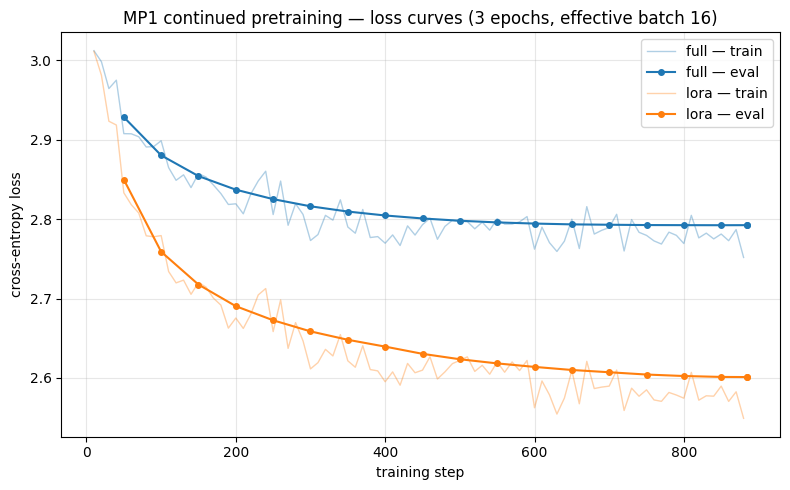

In [15]:
import json

OUTPUTS = PROJECT_ROOT / "outputs"


def load_curves(mode):
    """Return (train_steps, train_loss), (eval_steps, eval_loss) for a run."""
    hist = json.loads((RUN_DIR / mode / "log_history.json").read_text())
    train = [(e["step"], e["loss"]) for e in hist if "loss" in e]
    evals = [(e["step"], e["eval_loss"]) for e in hist if "eval_loss" in e]
    return train, evals


fig, ax = plt.subplots(figsize=(8, 5))
for mode, color in [("full", "tab:blue"), ("lora", "tab:orange")]:
    train, evals = load_curves(mode)
    ts, tl = zip(*train)
    es, el = zip(*evals)
    ax.plot(ts, tl, color=color, alpha=0.35, linewidth=1, label=f"{mode} — train")
    ax.plot(es, el, color=color, marker="o", markersize=4, label=f"{mode} — eval")

ax.set_xlabel("training step")
ax.set_ylabel("cross-entropy loss")
ax.set_title("MP1 continued pretraining — loss curves (3 epochs, effective batch 16)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Both runs converge smoothly with no divergence. LoRA's eval loss settles
**below** full fine-tuning's despite training only ~3.5 % of the parameters —
quantified next as perplexity.

In [16]:
evald = json.loads((RUN_DIR / "eval.json").read_text())
ppl = evald["perplexity"]
base = ppl["base"]

rows = []
for model in ["base", "full", "lora"]:
    p = ppl[model]
    rows.append({
        "model": {"base": "base SmolLM2-135M",
                  "full": "full fine-tuning",
                  "lora": "LoRA r=16"}[model],
        "in-domain ppl": p["in_domain"],
        "OOD ppl": p["ood"],
        "in-domain vs base": f'{(p["in_domain"] / base["in_domain"] - 1) * 100:+.0f}%',
        "OOD vs base": f'{(p["ood"] / base["ood"] - 1) * 100:+.0f}%',
    })

ppl_table = pd.DataFrame(rows).set_index("model")
print("Test-set perplexity (lower = better)\n")
ppl_table

Test-set perplexity (lower = better)



,in-domain ppl,OOD ppl,in-domain vs base,OOD vs base
model,,,,
base SmolLM2-135M,20.43,23.97,+0%,+0%
full fine-tuning,16.23,23.10,-21%,-4%
LoRA r=16,13.64,23.95,-33%,-0%


**Reading the table.**

- **Strong in-domain adaptation** — both runs cut in-domain perplexity sharply
  (full −21 %, LoRA −33 %): the model has absorbed job-posting style and vocabulary.
- **The adaptation is domain-specific** — OOD perplexity barely moves. IT job
  postings (Djinni) do **not** transfer to cross-industry postings (LinkedIn).
  This is exactly the generalisation question the experiment was designed to
  answer, and the answer is *no* — the gains are local to the trained domain.
- **LoRA adapted harder in-domain** than full fine-tuning. *Honest caveat:* LoRA
  also ran a higher learning rate (2e-4 vs 5e-5). The comparison controls
  effective batch size, epochs, schedule shape and data, but **not** the
  learning rate — each method keeps its own conventional working range, so LR is
  a confound to acknowledge rather than a clean result. Full fine-tuning
  generalised marginally (OOD 23.10 < base 23.97); LoRA did not.

In [17]:
gens = evald["generations"]
prompts = [g["prompt"] for g in gens["base"]]

for i, prompt in enumerate(prompts):
    print("=" * 80)
    print(f"PROMPT: {prompt!r}")
    print("=" * 80)
    for model in ["base", "full", "lora"]:
        print(f"\n--- {model} ---")
        print(gens[model][i]["output"])
    print()

PROMPT: 'We are looking for a'

--- base ---
We are looking for a new way to make a better product.

We are looking for a new way to make a better product.

We are looking for a new way to make a better product.

The new way to make a better product

The new way to make a better product

The new way to make a better product

The new way to make a better product



--- full ---
We are looking for a team of experienced and highly qualified developers to join our team.

We offer:

- 10+ years of experience in the development of mobile applications
- 10+ years of experience in the development of mobile applications
- 10+ years of experience in the development of web applications
- 10+ years of experience in the development of web applications
-

--- lora ---
We are looking for a Senior DevOps Engineer to join our team.

**Responsibilities:**
- Develop and maintain CI/CD pipelines for our DevOps team
- Collaborate with DevOps engineers to ensure continuous delivery of our products
- Collabo

**Generations (greedy decoding).** The base model loops and degenerates
(`"1.1.1.1..."`, repeated sentences). After continued pretraining both runs
produce recognisable job-posting prose — responsibilities, "We offer",
experience requirements, project-management language. Repetition under greedy
decoding persists, which is expected for a 135M-parameter model; MP2's SFT +
alignment stage targets exactly this output quality.

### MP1 summary

| | full fine-tuning | LoRA r=16 |
|---|---|---|
| trainable params | 134.5M (100%) | ~4.9M (~3.5%) |
| wall-clock (RTX 4090) | 8.3 min | 9.5 min |
| in-domain test ppl | 16.23 (−21%) | **13.64 (−33%)** |
| OOD test ppl | **23.10 (−4%)** | 23.95 (−0%) |

LoRA wins in-domain at a fraction of the trainable parameters; full fine-tuning
is the only run to nudge OOD perplexity below base. Both confirm the core
finding: **continued pretraining yields strong but domain-specific adaptation.**
The checkpoint carried into MP2 is `outputs/mp1-lora/` (best in-domain fit).

## 6. Try it yourself — interactive generation

The numbers in §5 are aggregate. This section loads the checkpoints and lets you
feed them **your own prompts**, inspecting generation quality directly.

Remember MP1 is a **continued-pretraining** model — a *text completer*, not a
chat model. Give it the **start** of a job posting and it continues; it will not
answer instruction-style prompts ("write a job description for a Java
developer") — that is MP2's job.

The logic lives in `src/generate_mp1.py`, which is also a standalone CLI:

```bash
.venv_atlm_pro/bin/python src/generate_mp1.py --model lora --prompt "We are looking for"
.venv_atlm_pro/bin/python src/generate_mp1.py --model all  --prompt "Senior Data Engineer"
.venv_atlm_pro/bin/python src/generate_mp1.py --model lora            # REPL
```

Decoding here uses **sampling** (temperature 0.8, top-p 0.95, repetition-penalty
1.3) rather than the greedy decoding of §5 — greedy maximises perplexity
comparability but reads worse.

In [3]:
import sys

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RUN = "mp1-135m"                                  # this notebook's output-folder tag
from generate_mp1 import load_model, generate

# Load all three checkpoints — the untrained base plus both adaptation methods —
# so generations can be compared the same three ways as the §5 perplexity table.
base_model, tokenizer = load_model("base", RUN)
full_model, _ = load_model("full", RUN)
lora_model, _ = load_model("lora", RUN)

MODELS = {"base": base_model, "full": full_model, "lora": lora_model}
print("loaded: base + full fine-tuned + LoRA-adapted SmolLM2-135M")

/home/logus/env/iscte/atlm_pro/.venv_atlm_pro/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3717.22it/s]


loaded: base + full fine-tuned + LoRA-adapted SmolLM2-135M


**Base vs full vs LoRA on the same prompts.** Each prompt is the opening of a
job posting — exactly the shape of text the model was continued-pretrained on.
The `base` row is the "before"; `full` and `lora` are the two trained variants.

In [4]:
prompts = [
    "Senior Backend Engineer\n\nWe are looking for",
    "Responsibilities:\n-",
    "Required skills:",
]

for p in prompts:
    print("=" * 80)
    print(f"PROMPT: {p!r}")
    print("=" * 80)
    for name, model in MODELS.items():
        print(f"\n--- {name} ---")
        print(generate(model, tokenizer, p, max_new_tokens=100))
    print()

PROMPT: 'Senior Backend Engineer\n\nWe are looking for'

--- base ---
Senior Backend Engineer

We are looking for an experienced developer to help us with our latest development project. We need a back end engineer who can develop and test the backend of web apps like CRM, CMS or even chat bot where we build products such as messaging software etc…



--- full ---
Senior Backend Engineer

We are looking for an experienced developer to join our team. We need a deep understanding of data science, machine learning and big-data analytics as well the ability to work within complex teams that will deliver results in near real time (10+ years experience). Experience with Python is also important but not necessary since we would like you into the main office on Linux desktops or Macs too! You should have good communication skills including effective use of technical support channels such as Zoom Video conferencing, Google docs etc., plus

--- lora ---
Senior Backend Engineer

We are looking fo

**Your turn.** Edit the prompt below and re-run — it generates from all three
checkpoints, so you see `base` ("before") against `full` and `lora`. Adjust
`temperature` / `max_new_tokens` to explore further.

In [5]:
my_prompt = "Data Scientist with experience in"

for name, model in MODELS.items():
    print(f"--- {name} ---")
    print(generate(model, tokenizer, my_prompt, max_new_tokens=120, temperature=0.8))
    print()

--- base ---
Data Scientist with experience in statistical and data science, or anyone who has an interest for the field.
280 points · 7 hours ago· (edited)

1 reply

--- full ---
Data Scientist with experience in:
+ Design, development and testing of AI systems; including machine learning algorithms such as LSTM. Strong understanding on optimization methods (eigenvector or gradient-based optimizers) for solving different types of problems using backpropagation algorithm is essential to perform well when we have high difficulty training the system via a dataset that contains large amounts of data being passed by hand through an implementation process involving manual features selection/selection from available set - this can be time consuming even though it provides great benefits like accuracy improvement over human trained model without any bias adjustment). Experience working directly within software team will provide you

--- lora ---
Data Scientist with experience in:
- Experience